In [1]:
# activate Julia environment in this folder
import Pkg
Pkg.activate(".")
using CairoMakie
using CSV
using Statistics
using CategoricalArrays
using DataFrames
using HDF5
using Random
using UnfoldStats
using UnfoldMakie
using MAT
using LinearAlgebra
using UnfoldSim
using UnfoldMixedModels
using MixedModelsPermutations
using ClusterDepth

ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
lmm_permutations = ext.lmm_permutations
get_lmm_statistic = ext.get_lmm_statistic

  Activating project at `/data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation`


get_lmm_statistic (generic function with 2 methods)

In [2]:
# import the new module 
include("/data/tu_grossmannr/PhDProject_Experimental/ClusterComputation/read_adjacency.jl")
include("/data/tu_grossmannr/PhDProject_Experimental/ClusterComputation/cluster_mass_test.jl") 

spatiotemporal_cluster_pvalues (generic function with 1 method)

## Show channel setup

In [3]:
# define custom channels
custom = ["Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2", "F7", "F8", "T7", "T8", "P7", "P8", "AFz", "Fz", "Cz", 
            "Pz", "FC1", "FC2", "CP1", "CP2", "FC5", "FC6", "CP5", "CP6", "FT9", "FT10", "F1", "F2", "C1", "C2", "P1", "P2", 
            "AF3", "AF4", "FC3", "FC4", "CP3", "CP4", "PO3", "PO4", "F5", "F6", "C5", "C6", "P5", "P6", "AF7", "AF8", "FT7", 
            "FT8", "TP7", "TP8", "PO7", "PO8", "Fpz", "CPz", "F9", "F10"]

# load custom channel topo
subject_id = "013"
custom_file = "./sub-" * subject_id * "_ses-mecha_task-NT_channel_adjacency.mat"

adjacency, matched_labels = read_fieldtrip_neighbors(
    custom_file;
    channel_order = custom  # Reorder to match layout (should not matter in this example, since we use all channels)
)

(Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], ["Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2"  …  "FT7", "FT8", "TP7", "TP8", "PO7", "PO8", "Fpz", "CPz", "F9", "F10"])

Please cite: HArtMuT: Harmening Nils, Klug Marius, Gramann Klaus and Miklody Daniel - 10.1088/1741-2552/aca8ce
Found 60 electrodes out of 62 requested


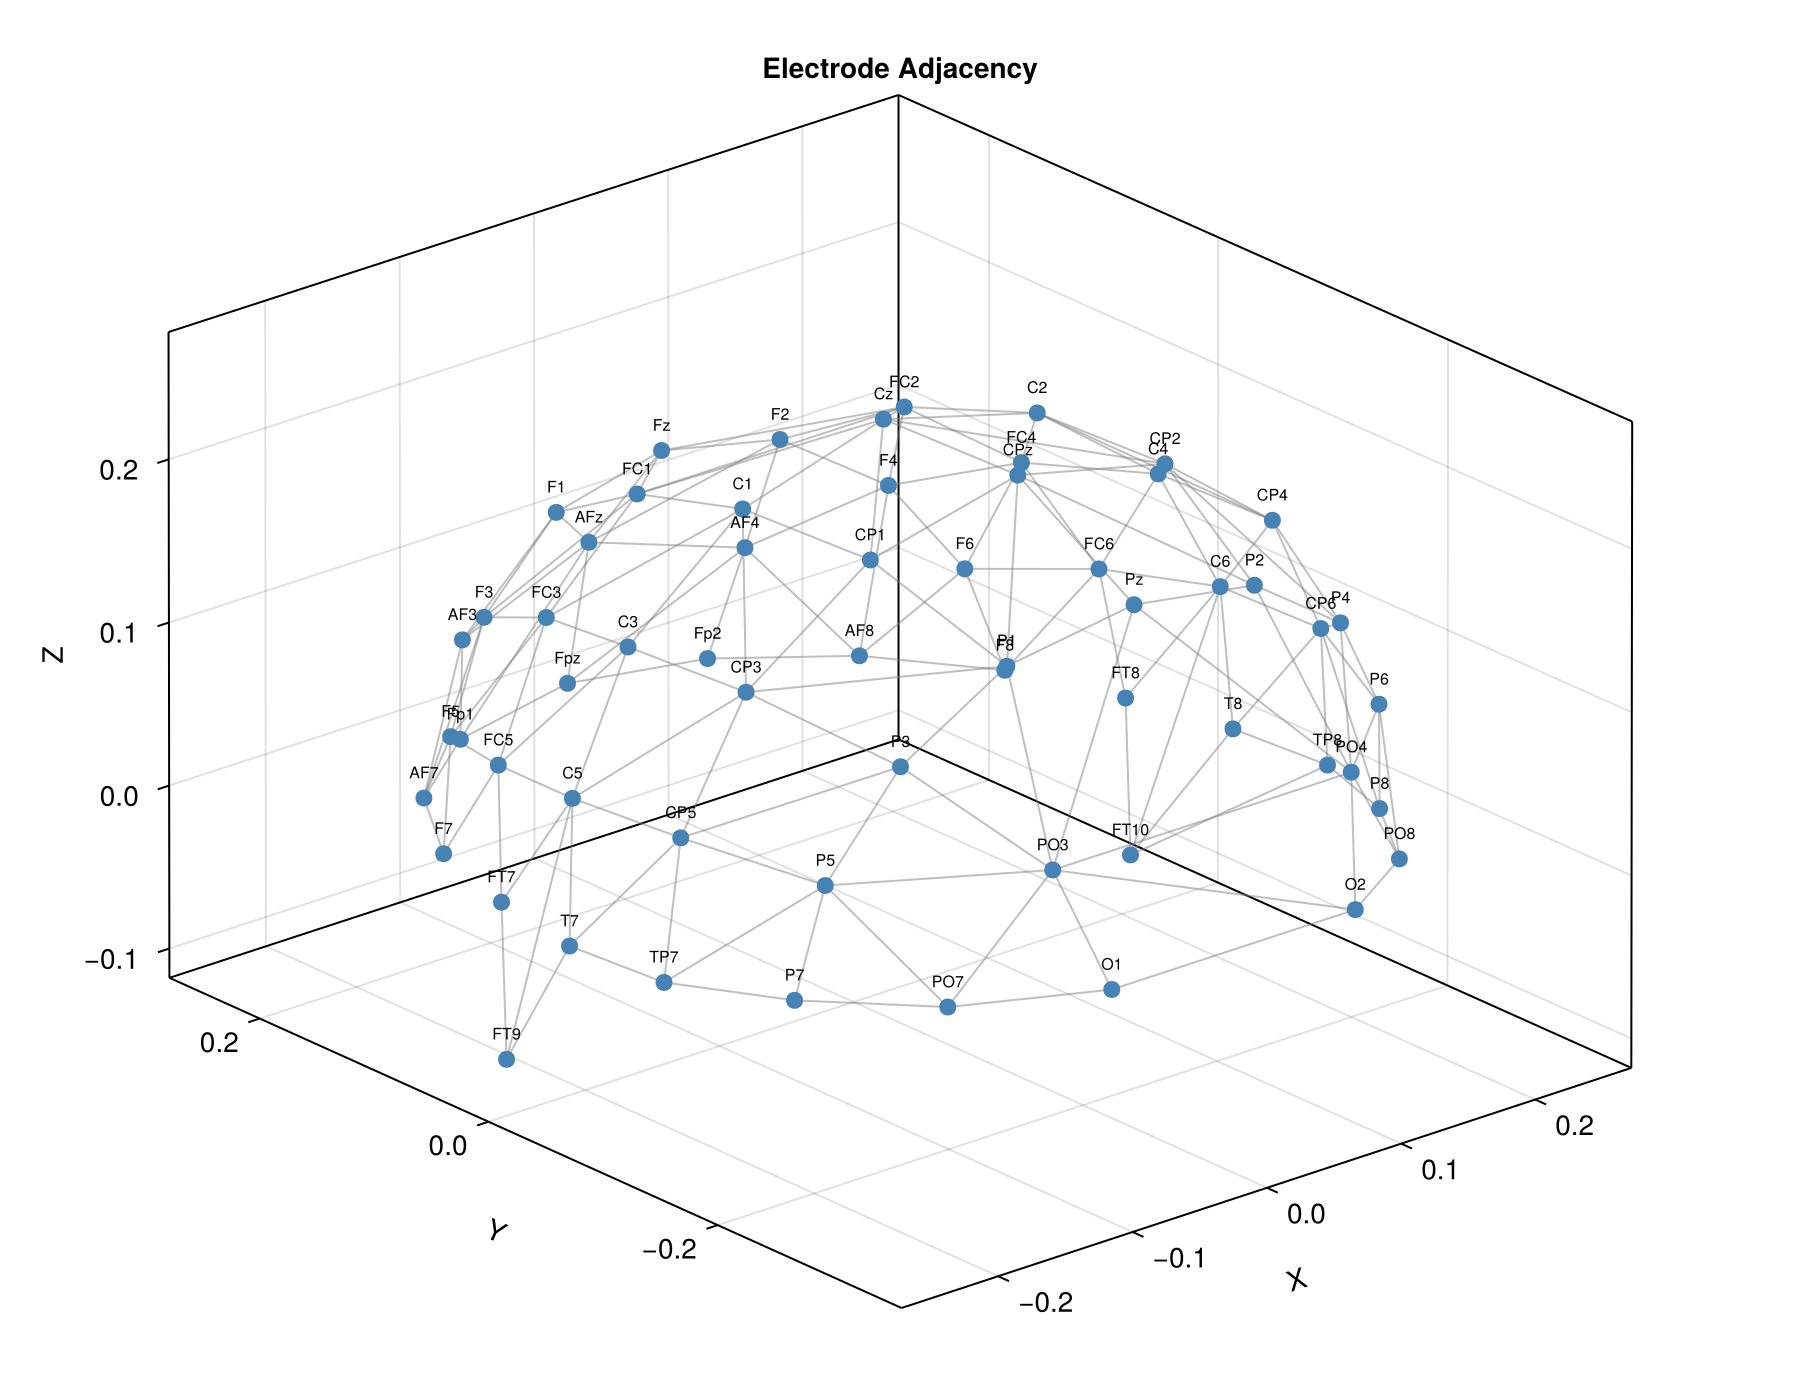

In [4]:
# Visualize the adjacency
# needed for visualization of adjacency and simulation of effects
hart = Hartmut()
# Find indices of channels in HArtMuT
all_labels = hart.electrodes["label"]
channel_idx_raw = [findfirst(==(ch), all_labels) for ch in custom]

# Filter out channels not found in HArtMuT and get their labels
found_mask = .!isnothing.(channel_idx_raw)
channel_idx = Int64[idx for idx in channel_idx_raw if !isnothing(idx)]
electrode_labels = custom[found_mask]


println("Found $(length(electrode_labels)) electrodes out of $(length(custom)) requested")

# Extract subset of electrode positions
electrode_positions = hart.electrodes["pos"][channel_idx, :]
found_indices_in_custom = findall(found_mask)

# Extract the submatrix for only the found channels
adjacency_subset = adjacency[found_indices_in_custom, found_indices_in_custom]

fig = Figure(size = (900, 700))
ax = Axis3(fig[1, 1],
    title = "Electrode Adjacency",
    xlabel = "X", ylabel = "Y", zlabel = "Z",
    aspect = :data)

pos3d = electrode_positions

# Draw connections between adjacent electrodes
for i in 1:size(adjacency_subset, 1)
    for j in (i+1):size(adjacency_subset, 2)
        if adjacency_subset[i, j]
            lines!(ax,
                [pos3d[i, 1], pos3d[j, 1]],
                [pos3d[i, 2], pos3d[j, 2]],
                [pos3d[i, 3], pos3d[j, 3]],
                color = (:gray, 0.5), linewidth = 1.0)
        end
    end
end

# Draw electrode points with labels
scatter!(ax, pos3d[:, 1], pos3d[:, 2], pos3d[:, 3],
    markersize = 12, color = :steelblue)

# Add electrode labels
for (i, label) in enumerate(electrode_labels)
    text!(ax, pos3d[i, 1], pos3d[i, 2], pos3d[i, 3] + 0.01,
        text = label, fontsize = 8, align = (:center, :bottom))
end

fig

## Load Data

In [5]:
# load functions from other script
include("./unfold_cluster_permutation.jl")

In [6]:
# specify loading parameters
datadir = get(ENV, "DATADIR", "")

if isempty(strip(datadir))
    error("DATADIR is not set. Example: export DATADIR=/data/p_02989/shared_workspace/datadir")
end

epoch_stem = get(ENV, "EPOCH_STEM", "epochs")
metadata_stem = get(ENV, "METADATA_STEM", "allmetadata")
subjects = parse_subjects()
modalities = parse_modalities()
resdir = get(ENV, "RESDIR", "")
outroot = isempty(strip(resdir)) ? joinpath(pwd(), "cluster_permutation") : joinpath(resdir, "Statistics", "eeg", "cluster_permutation")
n_permutations = parse(Int, get(ENV, "N_PERMUTATIONS", "2000"))
seed = parse(Int, get(ENV, "RNG_SEED", "1"))
plot_start_str = strip(get(ENV, "PLOT_START", ""))
plot_stop_str = strip(get(ENV, "PLOT_STOP", ""))
plot_start = isempty(plot_start_str) ? nothing : parse(Float64, plot_start_str)
plot_stop = isempty(plot_stop_str) ? nothing : parse(Float64, plot_stop_str)

# Add cropping parameters for analysis
time_start_str = strip(get(ENV, "TIME_START", "-0.1"))
time_stop_str = strip(get(ENV, "TIME_STOP", "0.25"))
time_start = isempty(time_start_str) ? nothing : parse(Float64, time_start_str)
time_stop = isempty(time_stop_str) ? nothing : parse(Float64, time_stop_str)
alpha = 0.05

# Create subject and trial tracking dataframes
subject_trial_counts = DataFrame(subject = String[], modality = String[], total_trials = Int[])
# Collect per-run/per-coefficient traces for end-of-script elec/mecha/combined figures.
comparison_store = Dict{String, Dict{String, NamedTuple}}()

# Mirror exclusion from existing analysis scripts.
excluded = Set([
    ("023", "mecha"),
    ("036", "mecha"),
])

# choose modality
ses = "mecha"

"mecha"

In [7]:
# run loading loop
# Run each modality as an independent model/permutation pipeline.
@info "Starting modality run" modality=ses

all_blocks = Array{Float64, 3}[]
all_events = DataFrame()
times_ref = nothing
channels_ref = nothing
requested_channels = nothing

for subid in subjects
    if (subid, ses) in excluded
        @info "Skipping excluded subject/session" subid ses
        continue
    end

    loaded = load_subject_session(
        datadir,
        subid,
        ses,
        requested_channels;
        epoch_stem = epoch_stem,
        metadata_stem = metadata_stem,
        time_start = time_start,
        time_stop = time_stop,
    )
    if isnothing(loaded)
        @info "Missing files, skipped." subid ses
        continue
    end

    if isnothing(times_ref)
        times_ref = loaded.times
    elseif length(times_ref) != length(loaded.times)
        error("Time axis mismatch for sub-$subid ses-$ses")
    end

    if isnothing(channels_ref)
        channels_ref = loaded.channels
    elseif loaded.channels != channels_ref
        error("Channel list mismatch for sub-$subid ses-$ses")
    end

    # Keep trial-wise EEG and metadata aligned while stacking blocks.
    push!(all_blocks, loaded.data)
    append!(all_events, loaded.events; promote = true)
    @info "Loaded block" subid ses n_trials=size(loaded.data, 3) n_channels=size(loaded.data, 1)
    
    # Count trials for this subject and modality
    total_trials = size(loaded.data, 3)
    
    # Add to subject trial counts dataframe
    push!(subject_trial_counts, (subject = "sub-$subid", modality = ses, total_trials = total_trials))
end


data_epoched = cat(all_blocks...; dims = 3)  # channel x time x trial
channels = Vector{String}(channels_ref)
n_channels = length(channels)
n_time = size(data_epoched, 2)


┌ Info: Starting modality run
│   modality = mecha
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X34sZmlsZQ==.jl:3
┌ Info: Excluding non-EEG channels from CHANNELS=all
│   excluded = ["CNAP", "ECG", "RESP", "VEOG"]
│   n_total = 66
│   n_eeg = 62
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/unfold_cluster_permutation.jl:88
┌ Info: Data cropped to time window
│   original_length = 451
│   cropped_length = 176
│   time_start = -0.1
│   time_stop = 0.25
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/unfold_cluster_permutation.jl:170
┌ Info: Loaded block
│   subid = 013
│   ses = mecha
│   n_trials = 883
│   n_channels = 62
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X34sZmlsZQ==.jl:47
┌ Info: Excludi

176

## Set up Model

In [8]:

# Modality-specific fixed effects:
# - Mechanical includes force as an additive factor.
# - Electrical keeps the original response/intensity model.
model_formula = nothing
if ses == "mecha"
    hasproperty(all_events, :force) || error("force column is required for modality 'mecha' but was not found.")

    # Drop trials with missing/empty/non-informative force values and keep EEG aligned.
    # This preserves strict row alignment by applying the exact same mask to metadata and EEG.
    n_trials_before = nrow(all_events)
    n_subjects_before = length(unique(all_events.sub))
    subjects_before = Set(string.(unique(all_events.sub)))

    forceq_str = lowercase.(strip.(string.(all_events.force)))
    keep_forceq = .!ismissing.(all_events.force) .&
                    .!(forceq_str .== "") .&
                    .!(forceq_str .== "nan") .&
                    .!(forceq_str .== "missing")

    dropped_trials = sum(.!keep_forceq)
    if dropped_trials > 0
        all_events = all_events[keep_forceq, :]
        data_epoched = data_epoched[:, :, keep_forceq]
    end

    n_trials_after = nrow(all_events)
    n_subjects_after = length(unique(all_events.sub))
    subjects_after = Set(string.(unique(all_events.sub)))
    removed_subjects = sort(collect(setdiff(subjects_before, subjects_after)))

    @info "Mechanical force filtering summary" dropped_trials n_trials_before n_trials_after n_subjects_before n_subjects_after removed_subjects
    n_trials_after > 0 || error("No trials left for modality 'mecha' after dropping missing force values.")
    n_subjects_after > 0 || error("No subjects left for modality 'mecha' after dropping missing force values.")

    # Recompute centered predictors after trial filtering so the
    # design matrix reflects the exact trial set used for model fit.
    all_events.intensity_level_centered = all_events.intensity_level .- mean(all_events.intensity_level)
    all_events.block_centered = all_events.block .- mean(all_events.block)
    # `force` can be Union{Missing,Float64}; after filtering there should
    # be only valid numeric trials, so center with skipmissing explicitly.
    mean_force = mean(skipmissing(all_events.force))
    all_events.force_centered = Float64.(all_events.force) .- mean_force

    # Use additive force effect for mechanical runs.
    model_formula = @formula(0 ~ 1 + intensity_level_centered * response_decoded + force_centered + (1 | sub) + (0 + block_centered | sub))
else
    # Electrical branch does not include force in the model.
    all_events.intensity_level_centered = all_events.intensity_level .- mean(all_events.intensity_level)
    all_events.block_centered = all_events.block .- mean(all_events.block)
    model_formula = @formula(0 ~ 1 + intensity_level_centered * response_decoded + (1 | sub) + (0 + block_centered | sub))
end
formula_string = string(model_formula)


┌ Info: Mechanical force filtering summary
│   dropped_trials = 4781
│   n_trials_before = 25780
│   n_trials_after = 20999
│   n_subjects_before = 35
│   n_subjects_after = 33
│   removed_subjects = ["22", "29"]
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl:32


"0 ~ 1 + intensity_level_centered + response_decoded + force_centered + intensity_level_centered & response_decoded + :(1 | sub) + :((0 + block_centered) | sub)"

In [9]:
# PLOT 
#run_id, run_dir, runs_root, modality_tag, formula_id = make_run_paths(outroot, [ses], formula_string)
#mkpath(run_dir)
#@info "Run output directory" run_id run_dir modality=ses

# Keep PLOT_CHANNEL as the backwards-compatible default target.
plot_channel_default = channels[9]
plot_channel = String(strip(get(ENV, "PLOT_CHANNEL", plot_channel_default)))
plot_channel in channels || error("PLOT_CHANNEL '$plot_channel' not found in analyzed channels: $(join(channels, ", "))")

# PLOT_CHANNELS allows plotting multiple channels in one figure.
plot_channels = parse_plot_channels(channels, plot_channel)
@info "Plot channel selection" n_selected=length(plot_channels) selected=plot_channels

# Save a plain ERP preview for the first selected channel.
preview_channel = plot_channels[1]
preview_idx = findfirst(==(preview_channel), channels)
data_preview = Matrix(data_epoched[preview_idx, :, :])  # time x trial

run_dir = "."
plot_erp(times_ref, data_preview, all_events, run_dir, preview_channel)

┌ Info: Plot channel selection
│   n_selected = 1
│   selected = ["C4"]
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X41sZmlsZQ==.jl:13
┌ Info: Saved ERP plot
│   outfile = ./erp_response_decoded_channel-C4.pdf
└ @ Main /data/p_02989/shared_workspace/grossmannr_wd/Analysis/EEGAnalysis/ClusterPermutation/unfold_cluster_permutation.jl:425


"./erp_response_decoded_channel-C4.pdf"

In [10]:
# fit model
m = fit(
    UnfoldModel,
    [Any => (model_formula, times_ref)],
    all_events,
    data_epoched,
)

@info "Model fit complete" modality=ses n_trials=size(data_epoched, 3) n_timepoints=size(data_epoched, 2)
target_coefs, coef_names = resolve_target_coefficients(m)
if ses == "mecha"
    # Mechanical model: also test every force level coefficient.
    target_coefs = append_factor_coefficients(target_coefs, coef_names, "force")
end
@info "Target coefficients resolved" modality=ses target=target_coefs available=coef_names


Progress:   0%|                                         |  ETA: 0:35:24

Progress:   9%|███▊                                     |  ETA: 0:00:12

Progress:  11%|████▌                                    |  ETA: 0:00:11

Progress:  12%|█████                                    |  ETA: 0:00:10

Progress:  14%|█████▋                                   |  ETA: 0:00:10

Progress:  15%|██████▎                                  |  ETA: 0:00:09

Progress:  17%|██████▉                                  |  ETA: 0:00:09

Progress:  18%|███████▍                                 |  ETA: 0:00:08

Progress:  19%|████████                                 |  ETA: 0:00:08

Progress:  21%|████████▌                                |  ETA: 0:00:08

Progress:  22%|█████████▏                               |  ETA: 0:00:08

Progress:  24%|█████████▊                               |  ETA: 0:00:07

Progress:  25%|██████████▍                              |  ETA: 0:00:07

Progress:  27%|███████████                         

In [ ]:
for electrode in channels

    c6_index = findfirst(==(electrode), channels)
    yes_trials = findall(all_events.response_decoded .=="Yes")
    no_trials = findall(all_events.response_decoded .=="No")
    erp_yes = mean(data_epoched[c6_index, :, yes_trials]; dims=2)[:]
    erp_no = mean(data_epoched[c6_index, :, no_trials]; dims=2)[:]


    # Plot
    fig = Figure(size=(600,400))
    ax = Axis(fig[1,1], xlabel="Time (s)", ylabel="Amplitude (a.u.)", title=electrode)
    lines!(ax, times_ref, erp_yes, color=:red, label="Yes")
    lines!(ax, times_ref, erp_no, color=:blue, label="No")
    axislegend(ax)
    display(fig)
end

## Set-up cluster-based permutation test


In [ ]:
coefficient = 1  # 1: intensity effect, 2: yes/no effect 
n_permutations = 2000  # Reduced for dev; use 500-1000 for real analyses
threshold = 2.0

time_selection = 1:length(times_ref)

println("Generating permutation distribution...")
permuted = lmm_permutations(MersenneTwister(42), m, data_epoched, coefficient; 
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection
)


In [28]:
# Check uncorrected effects before running permutation test
# Extract coefficients for the stimtype effect
coefs = coeftable(m)

# Show available columns
println("Available columns: $(names(coefs))")

# Filter for stimtype coefficient
coef_stimtype = filter(r -> r.coefname == "response_decoded: Yes", coefs)
println("Rows for response: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(coef_stimtype.time))
println("Unique channels: $(length(unique_channels))")
println("Unique times: $(length(unique_times))")


Available columns: ["channel", "coefname", "estimate", "eventname", "group", "stderror", "time"]
Rows for response: 10912
Unique channels: 62
Unique times: 176



=== Uncorrected Effects (before permutation) ===
Max |z|: 7.28
Peak location: channel F7 at t = 0.142s
Samples with |z| > 2.0: 2261 / 10912
Samples with |z| > 1.96: 2368 (uncorrected p < 0.05)


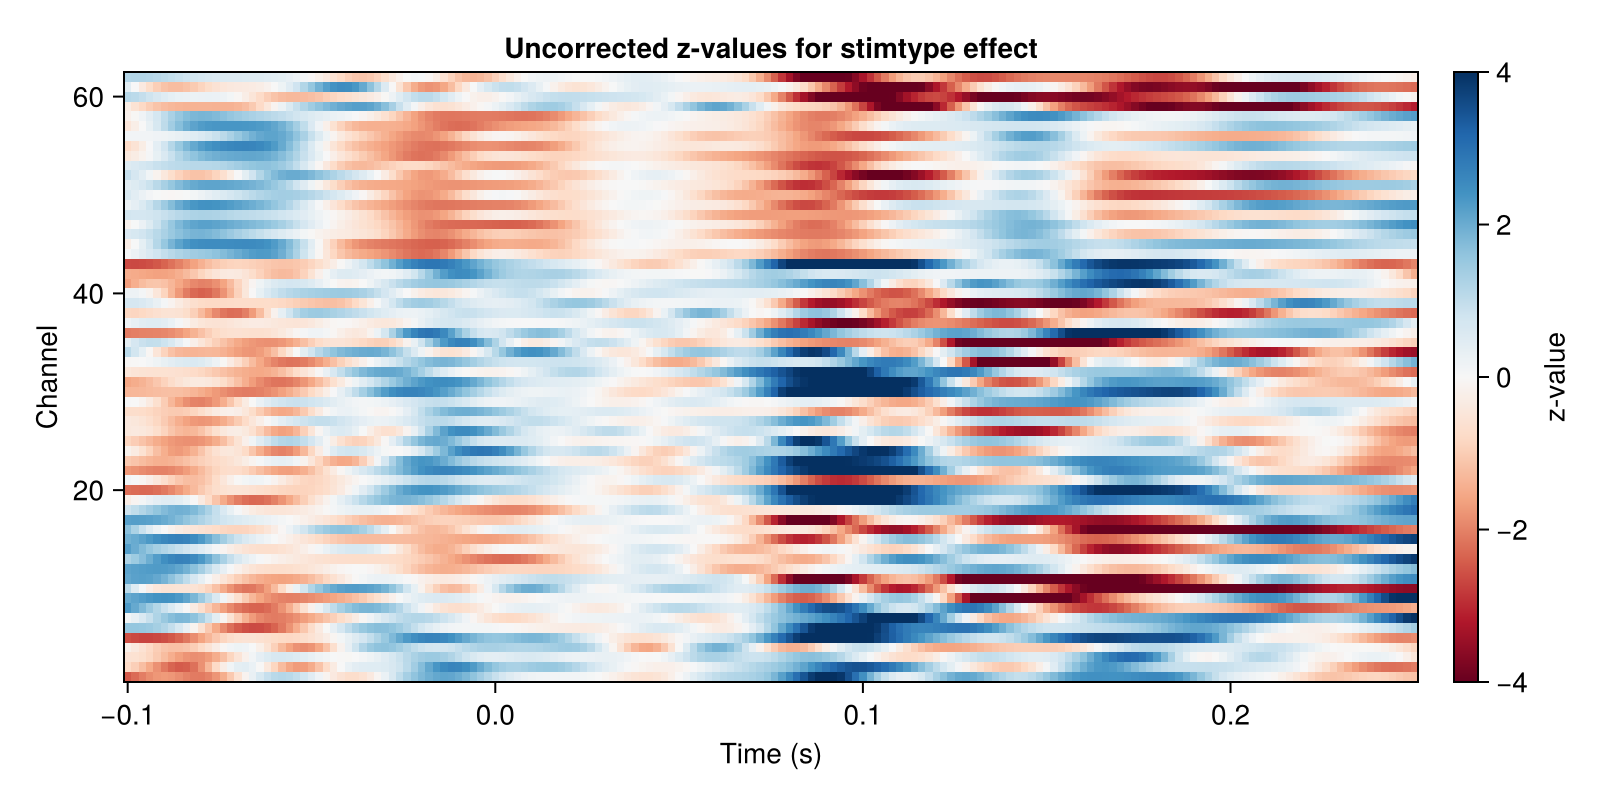

In [79]:

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate]
stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
z_vec = estimate_vec ./ stderror_vec

coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
z_summary = combine(
    groupby(coef_stimtype, [:channel, :time]),
    :z => (x -> mean(filter(!isnan, x))) => :z
)
sort!(z_summary, [:channel, :time])

# Replace NaN with 0 for visualization
z_summary.z = replace(z_summary.z, NaN => 0.0)

# Reshape z-values to channels × times
n_ch_coef = length(unique_channels)
n_t_coef = length(unique_times)
z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 2.0)
n_sig_uncorrected = sum(abs.(z_vals) .> 2.0)
max_z = maximum(abs.(z_vals))
peak_idx = argmax(abs.(z_vals))
peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

println("\n=== Uncorrected Effects (before permutation) ===")
println("Max |z|: $(round(max_z, digits=2))")
println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of z-values
fig_z = Figure(size = (800, 400))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected z-values for stimtype effect",
    xlabel = "Time (s)",
    ylabel = "Channel")
hm = heatmap!(ax_z, collect(unique_times), 1:n_ch_coef, z_vals', colormap = :RdBu, colorrange = (-4, 4))
Colorbar(fig_z[1, 2], hm, label = "z-value")
fig_z

## Run permutation test

Significant cluster IDs: [-38, -35, -26, 29, 42]


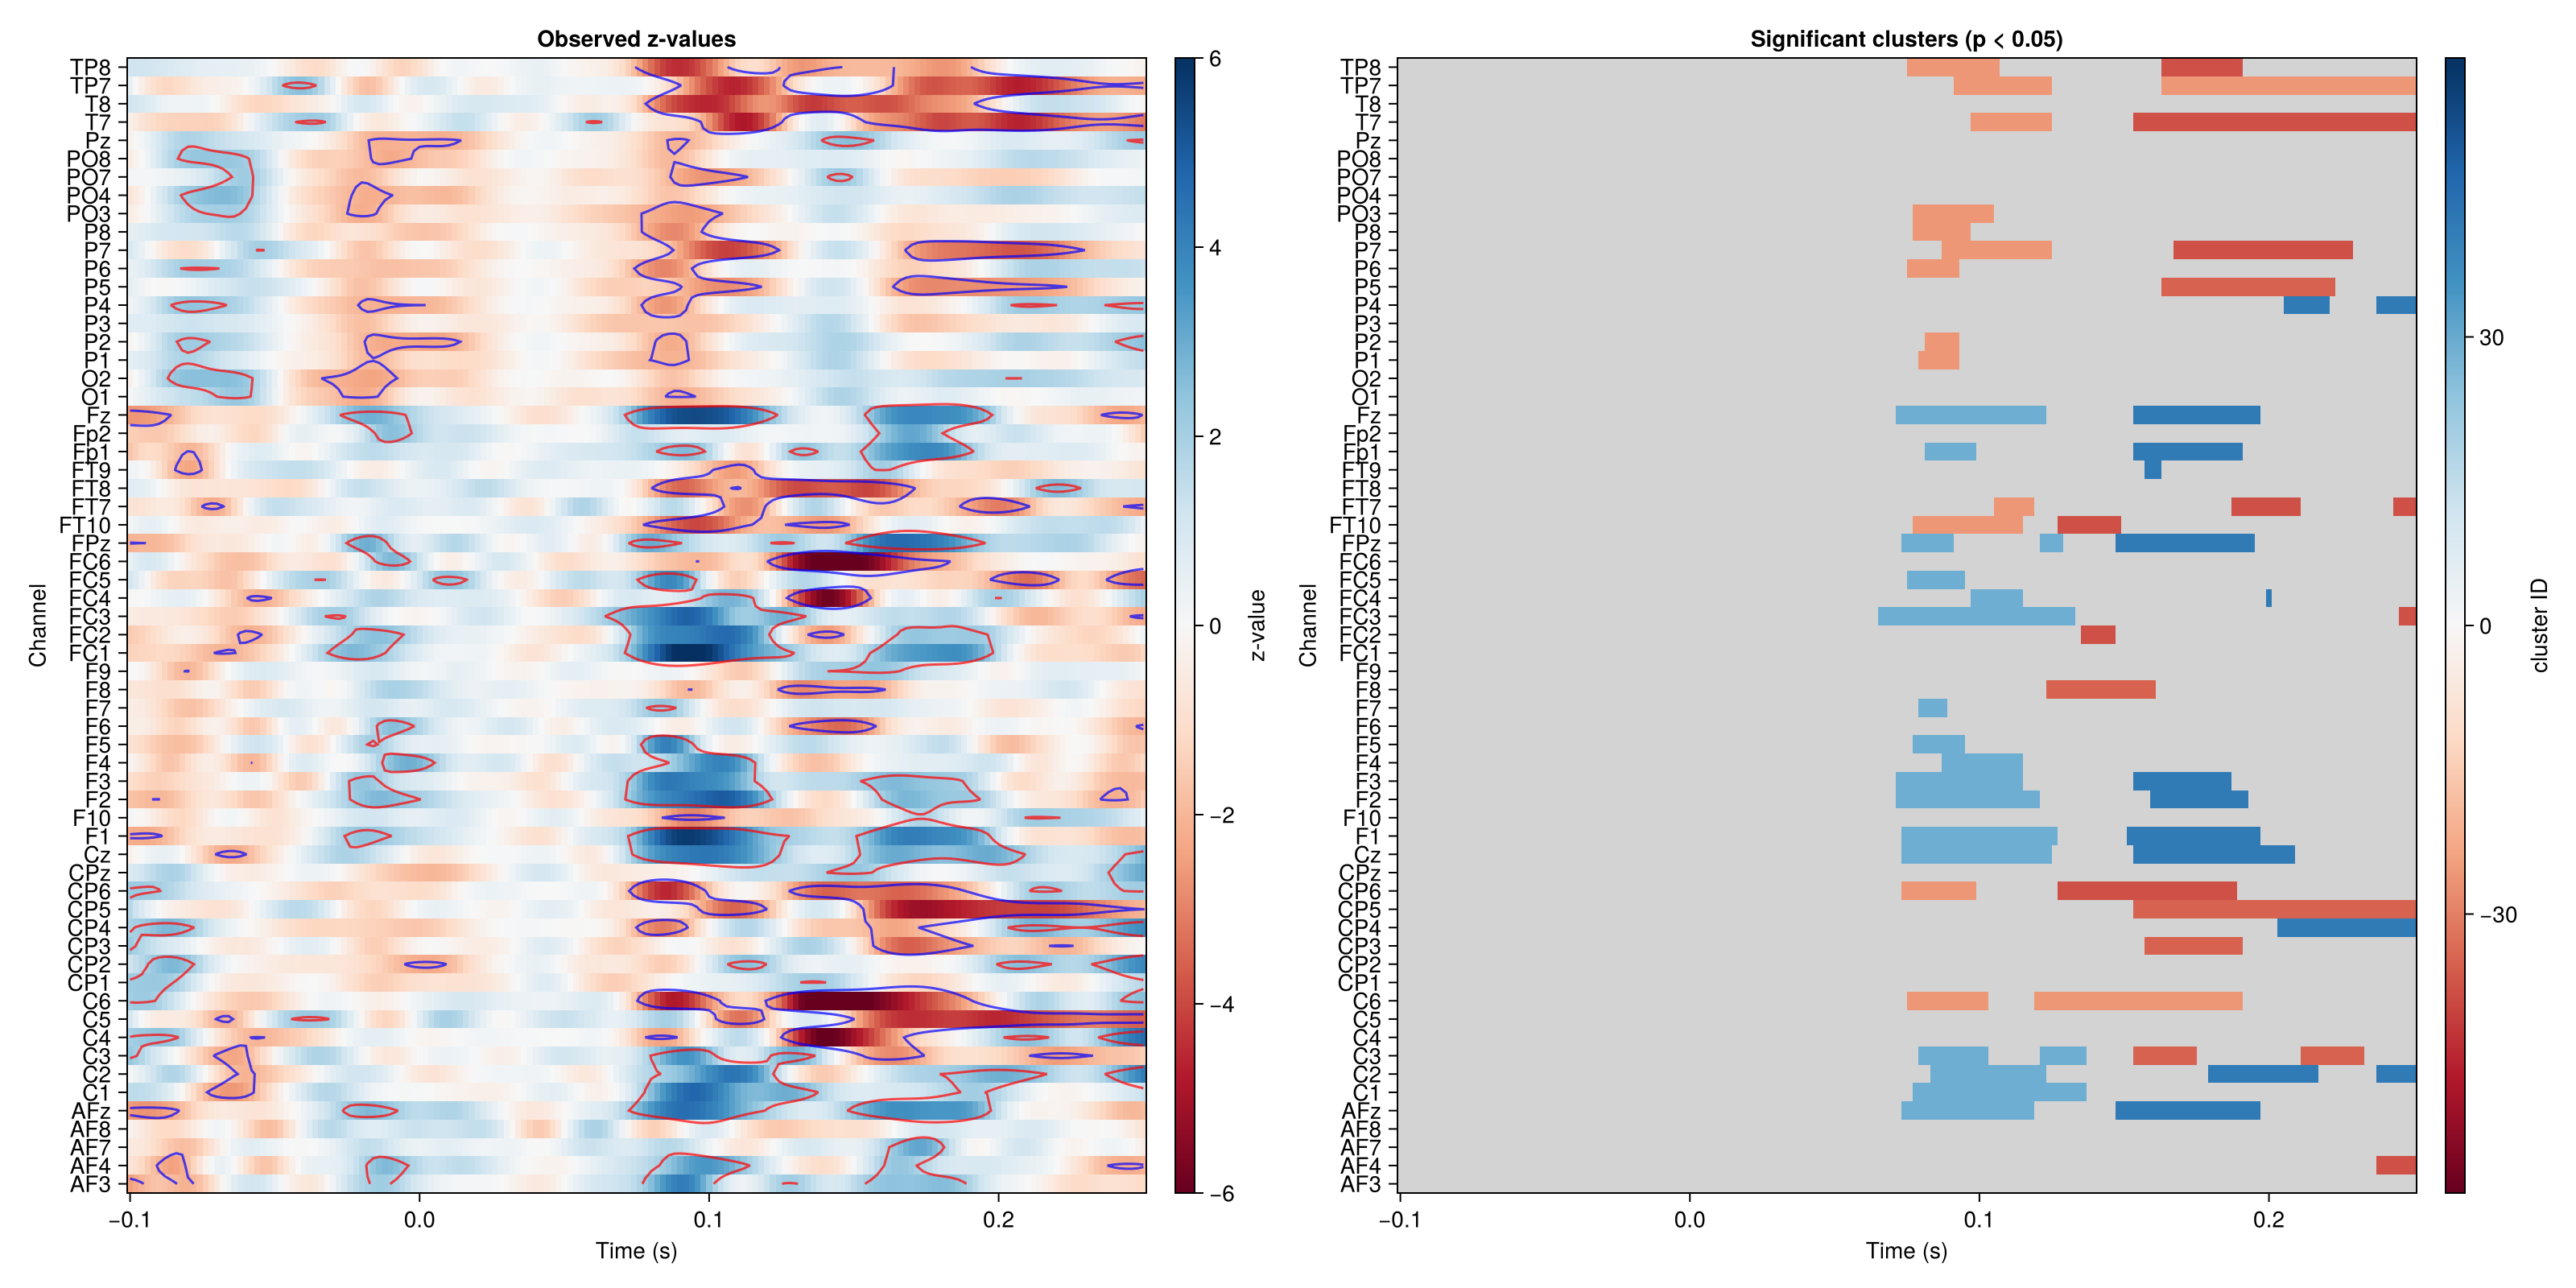

In [80]:
# 3. Run cluster-mass permutation test
observed = z_vals
pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, channels))
hm1 = heatmap!(ax1, collect(times_ref), 1:n_channels, z_vals', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times_ref), 1:n_channels, z_vals', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times_ref), 1:n_channels, z_vals', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel", yticks = (1:n_channels, channels))
hm2 = heatmap!(ax2, collect(times_ref), 1:n_channels, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

In [69]:
save("cluster_results.pdf", fig)

CairoMakie.Screen{PDF}


In [73]:
channels_ordered = [
# Frontal
"Fp1","AF7","AF3","F7","F5","F3","F1",
"FPz","AFz","Fz",
"Fp2","AF4","AF8","F2","F4","F6","F8",

# Frontocentral
"FT9","FT7","FC5","FC3","FC1",
"FC2","FC4","FC6","FT8","FT10",

# Central (Somatosensory)
"T7","C5","C3","C1",
"Cz",
"C2","C4","C6","T8",

# Centroparietal
"TP7","CP5","CP3","CP1",
"CPz",
"CP2","CP4","CP6","TP8",

# Parietal
"P7","P5","P3","P1",
"Pz",
"P2","P4","P6","P8",

# Parieto-occipital
"PO7","PO3",
"PO4","PO8",

# Occipital
"O1","O2",

# Remaining lateral frontal (if you want them at the end)
"F9","F10"
]


62-element Vector{String}:
 "Fp1"
 "AF7"
 "AF3"
 "F7"
 "F5"
 "F3"
 "F1"
 "FPz"
 "AFz"
 "Fz"
 ⋮
 "P8"
 "PO7"
 "PO3"
 "PO4"
 "PO8"
 "O1"
 "O2"
 "F9"
 "F10"

In [81]:
perm = indexin(channels_ordered, channels)

z_vals_sorted = z_vals[perm, :]
cluster_display_sorted = cluster_display[perm, :]

62×176 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱         ⋮                        ⋮
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN 

In [1]:
sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, channels_ordered))
hm1 = heatmap!(ax1, collect(times_ref), 1:n_channels, z_vals_sorted', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times_ref), 1:n_channels, z_vals_sorted', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times_ref), 1:n_channels, z_vals_sorted', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel", yticks = (1:n_channels, channels_ordered))
hm2 = heatmap!(ax2, collect(times_ref), 1:n_channels, cluster_display_sorted',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

UndefVarError: UndefVarError: `cluster_ids` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [85]:
save("cluster_results.pdf", fig)

CairoMakie.Screen{PDF}


In [89]:
using NPZ

# Save numeric arrays only
npzwrite("cluster_results.npz", Dict(
    "z_vals" => z_vals,
    "cluster_display" => cluster_display,
    "times" => collect(times_ref)
))

# Save channel names separately
open("channels.txt", "w") do f
    for ch in channels
        println(f, ch)
    end
end